In [1]:
import os
import ast

if 'PATH_SET' not in locals():
    os.chdir('..')
    PATH_SET = True
    
import torch    

if 'THREADS_SET' not in locals():
    try:
        os.environ['OMP_NUM_THREADS'] = '4'
        os.environ['MKL_NUM_THREADS'] = '4'
        
        torch.set_num_threads(4)
        torch.set_num_interop_threads(4)
        THREADS_SET = True
    except:
        pass

import numpy as np
import xarray as xr
import pandas as pd
from scipy.interpolate import RegularGridInterpolator

from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib.style as style
style.use('https://raw.githubusercontent.com/dominik-strutz/dotfiles/main/mystyle_background.mplstyle')

In [2]:
from helpers.geographic_setup import (
    design_space_full,
    topo_data,
    grid_coords
)

from helpers.helper_functions import (
    SurfaceField_Distribution,
    concave_hull2D_prior_dist_constructor,
)

from helpers.likelihood import (
    DataLikelihoodAttenuation,
    DataLikelihood,
    logistic_picking_likelihood_tt)
from helpers.forward import (
    TTLookup, Homogeneous_Forward_Function)

from helpers.transparent_colormaps import (
    blue_cmap
)

In [3]:
concave_hull2D_prior = concave_hull2D_prior_dist_constructor(
    design_space_full[..., :2],
    topo_data,
    buffer=20,
    depth=0,
    ratio=0.05,
    base_dist='sobol'
)

In [4]:
dx = 20

x = torch.from_numpy(topo_data['easting'].values).float()
y = torch.from_numpy(topo_data['northing'].values).float()
z = torch.from_numpy(topo_data.values).float()

x_posterior = torch.arange(
    x.min()+100, x.max()-200, dx)
y_posterior = torch.arange(
    y.min()+100, y.max()-200, dx)
z_posterior = torch.arange(
    topo_data.min().item()-100, topo_data.max().item()+1, dx)

In [5]:
X_posterior, Y_posterior, Z_posterior = torch.meshgrid(
    x_posterior, y_posterior, z_posterior, indexing='ij')    

indices = torch.arange(Z_posterior.numel())
posterior_grid_full = torch.stack(
    [X_posterior.ravel(), Y_posterior.ravel(),
     Z_posterior.ravel(), indices], dim=-1)
print(f'Memory usage: {posterior_grid_full.element_size()*posterior_grid_full.nelement()/1e6:.2f} MB')

Memory usage: 12.78 MB


In [6]:
file_name_m_prior = 'data/priors/surface_displacement_prior.pt'

model_prior_sd = SurfaceField_Distribution(
    distibution=torch.load(file_name_m_prior, weights_only=False).forward(),
    topo_data=topo_data,
    depth=300,
)

N_test = 100
torch.manual_seed(0)
test_events = model_prior_sd.sample((N_test,))

In [7]:
# forward_function_heterogenous =  TTLookup(
#     posterior_grid_full, design_space_full,
#     torch.load('data/data_lookup/heterogeneous_full_posterior.pt'),
# )

forward_function_heterogenous = Homogeneous_Forward_Function(
    1500.0)

picking_likelihood = logistic_picking_likelihood_tt(b = -30, c = 0.35,)


data_likelihood_het_att = DataLikelihoodAttenuation(
    forward_function=forward_function_heterogenous,
    dependence_distance=150,
    picking_likelihood=picking_likelihood,
    vel_sigma=0.05,
    tt_obs_std=0.01, 
)

data_likelihood_het = DataLikelihood(
    forward_function=forward_function_heterogenous,
    dependence_distance=150,
    vel_sigma=0.05,
    tt_obs_std=0.01, 
)

In [8]:
design_df_raw = pd.read_csv('generate_designs/data/design_data.csv')
design_df = design_df_raw[design_df_raw['study_area'] == 'full']
# Reset DataFrame indices to avoid potential issues
design_df = design_df.reset_index(drop=True)

# Check for missing or problematic columns
required_columns = ['study_area', 'model_prior', 'velocity_model', 'vel_sigma', 
                   'noise_correlation', 'drop_mean', 'drop_gradient', 
                   'optimisation', 'EIG_method', 'EIG_N', 'design']
missing_columns = [col for col in required_columns if col not in design_df.columns]
if missing_columns:
    print(f"Warning: Missing columns in design_df: {missing_columns}")

# Convert design column from string to tensor if needed
if 'design' in design_df.columns and isinstance(design_df['design'].iloc[0], str):
    design_df['design'] = design_df['design'].apply(lambda x: torch.tensor(ast.literal_eval(x)))

print(f'Number of designs: {len(design_df)}')
print(f'Number of events : {len(test_events)}')

Number of designs: 3099
Number of events : 100


In [9]:
with torch.no_grad():
    log_p_prior_original = model_prior_sd.log_prob(posterior_grid_full, fast_eval=False)
    log_p_prior_original = log_p_prior_original.reshape(X_posterior.shape)

p_prior = log_p_prior_original.exp()
p_prior = p_prior / torch.nansum(p_prior) # for some reason prior is not normalized, do it here

prior_mask = log_p_prior_original.isfinite()

log_p_prior = p_prior.log()
log_p_prior[~prior_mask] = torch.nan

In [23]:
def calculate_posterior(event_idx, design):
    """
    Calculate posterior distribution for event location given a design setup.
    
    Args:
        event_idx: Index of the event from test_events to use
        design_idx: Index of the design from design_df to use
        
    Returns:
        dict: Dictionary containing the posterior, likelihood, prior, event details, design details
    """
    event = test_events[event_idx][..., :3]

    print(event.shape, design.shape)


    torch.manual_seed(0)
    dl = data_likelihood_het_att(
            torch.tensor([0.5]).unsqueeze(0), event.unsqueeze(0), design
        )
    tt_obs = dl.sample().squeeze(0)
    tt_obs_cov = dl.scale_tril

    std_diag = torch.sqrt(torch.diagonal(tt_obs_cov.squeeze(0)))
    mask = std_diag < 0.5

    design_tmp = design[mask]
    tt_obs = tt_obs[mask]
    tt_obs_cov = tt_obs_cov[..., mask, :][..., mask]

    if len(tt_obs) < 1:
        log_p_posterior = log_p_prior
    else:
        log_p_likelihood = data_likelihood_het(
            posterior_grid_full[prior_mask.flatten()],
            design_tmp,
            posterior_cov=tt_obs_cov,
        ).log_prob(tt_obs)

        log_p_unnormalised_posterior = (
            log_p_likelihood + log_p_prior.flatten()[prior_mask.flatten()]
        )
        log_p_evidence = torch.logsumexp(
            log_p_unnormalised_posterior, dim=0
        )

        log_p_posterior = torch.full_like(log_p_prior, -np.inf).flatten()
        log_p_posterior[prior_mask.flatten()] = (
            log_p_unnormalised_posterior - log_p_evidence
        )
        log_p_posterior = log_p_posterior.reshape(X_posterior.shape)

    p_prior_out = log_p_prior.clone().exp()
    p_posterior_out = log_p_posterior.exp()

    p_likelihood = torch.full_like(log_p_prior, 0).flatten()
    p_likelihood[prior_mask.flatten()] = log_p_likelihood.exp()
    p_likelihood = p_likelihood.reshape(X_posterior.shape)
    
    
    results = {
        'posterior': p_posterior_out,
        'likelihood': p_likelihood,
        'prior': p_prior_out,
        'log_prior': log_p_prior,
        'event': {'tensor': event,
                 'x': event[0].item(), 
                 'y': event[1].item(), 
                 'z': event[2].item()},
        'design': {'full': design, 'filtered': design_tmp},
        'mask': mask
    }
    
    
    return results

# # Run with default parameters
# results = calculate_posterior()

# # Extract common variables for compatibility with existing code
# p_posterior = results['posterior']
# p_prior = results['prior']
# event_x, event_y, event_z = results['event']['x'], results['event']['y'], results['event']['z']
# design = results['design']['full']
# design_tmp = results['design']['filtered']

In [24]:
from helpers.helper_functions import get_design_information

In [25]:
scenario = dict(
    study_area='full',)


torch.Size([3]) torch.Size([4, 3])
torch.Size([3]) torch.Size([4, 3])
torch.Size([3]) torch.Size([4, 3])
torch.Size([3]) torch.Size([6, 3])
torch.Size([3]) torch.Size([6, 3])
torch.Size([3]) torch.Size([6, 3])
torch.Size([3]) torch.Size([10, 3])
torch.Size([3]) torch.Size([10, 3])
torch.Size([3]) torch.Size([10, 3])


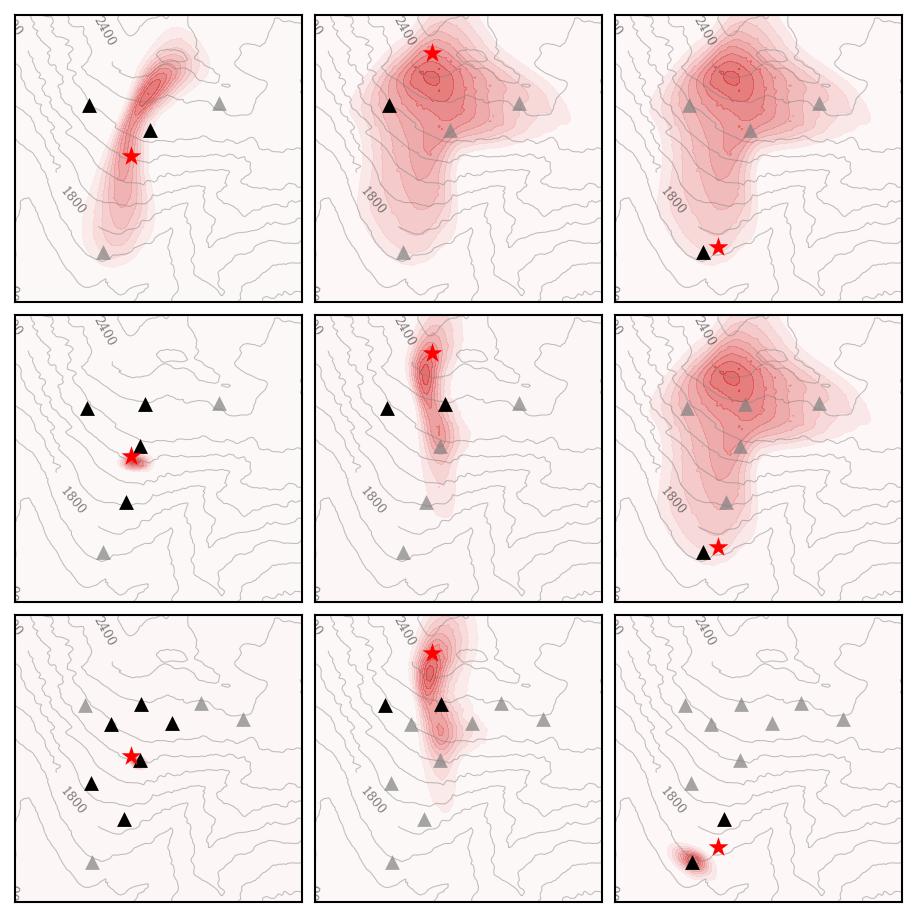

torch.Size([3]) torch.Size([4, 3])
torch.Size([3]) torch.Size([4, 3])
torch.Size([3]) torch.Size([4, 3])
torch.Size([3]) torch.Size([6, 3])
torch.Size([3]) torch.Size([6, 3])
torch.Size([3]) torch.Size([6, 3])
torch.Size([3]) torch.Size([10, 3])
torch.Size([3]) torch.Size([10, 3])
torch.Size([3]) torch.Size([10, 3])


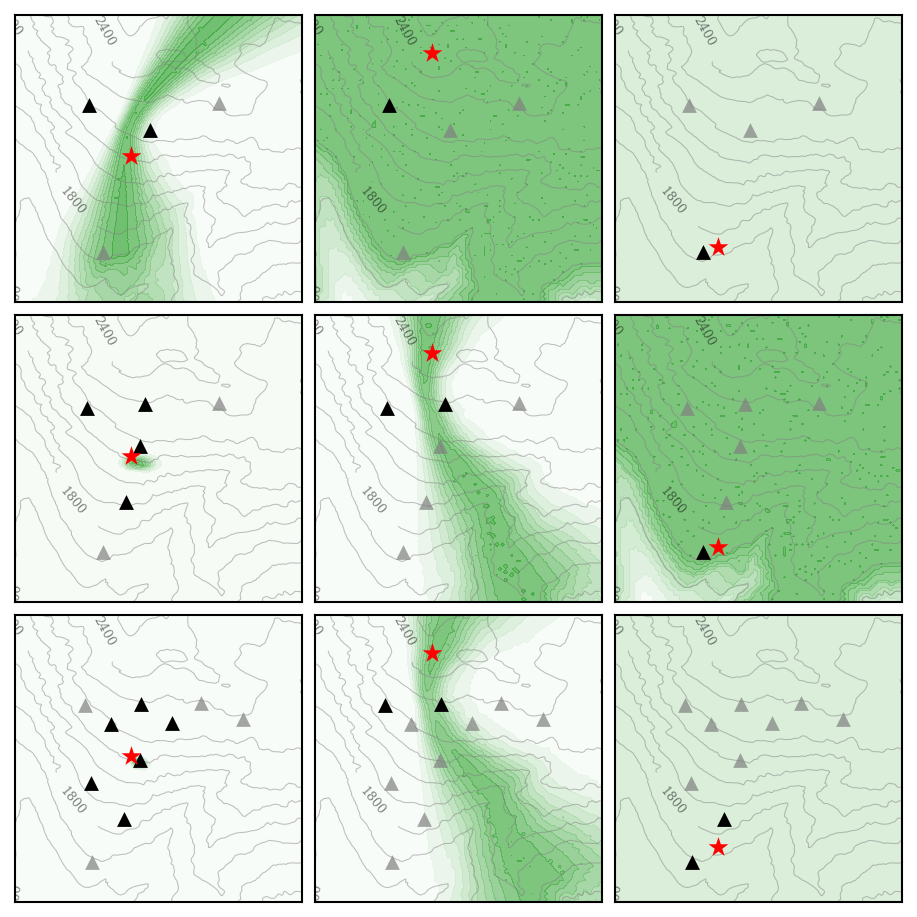

In [26]:
def plot_designs_vs_events(
    rec_indices, event_indices, scenario, n_rows=None, n_cols=None, field='posterior'):
    """
    Plot a grid of subplots showing data likelihood for multiple designs and events.
    
    Args:
        design_indices (list): List of design indices to use
        event_indices (list): List of event indices to use
        n_rows (int, optional): Number of rows in the grid. Defaults to len(design_indices).
        n_cols (int, optional): Number of columns in the grid. Defaults to len(event_indices).
    """
    n_design = len(rec_indices)
    n_src = len(event_indices)
    
    choosen_design = get_design_information(design_df_raw, scenario)['design']    
    
    # Set default grid layout if not specified
    if n_rows is None:
        n_rows = n_design
    if n_cols is None:
        n_cols = n_src
    
    # Create figure with white background
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2, n_rows*2), 
                            facecolor='white', constrained_layout=True)
    
    # Handle single row or column case
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)
    
    x_min, x_max = 100, 2000
    y_min, y_max = 100, 2200
    
    # Plot each combination of design and event
    for i, design_idx in enumerate(rec_indices):
        for j, event_idx in enumerate(event_indices):
            ax = axes[i % n_rows, j % n_cols]
            
            # Calculate posterior for this design-event combination
            design = torch.tensor(choosen_design[design_idx-2])[..., :3]

            # try:
            result = calculate_posterior(
                event_idx=event_idx, design=design)
            
            # Extract key data
            event = result['event']['tensor']
            design = result['design']['full']
            design_tmp = result['design']['filtered']

            # Calculate marginal posterior over z for visualization
            if field in result:
                z_marginal_post = torch.nanmean(result[field], dim=2)
            
                from matplotlib.colors import LinearSegmentedColormap
                cmap_green = LinearSegmentedColormap.from_list('', ['white', 'tab:green'])
                cmap_red = LinearSegmentedColormap.from_list('', ['white', 'tab:red'])  
            
                # Plot the posterior as contours
                ax.contourf(x_posterior, y_posterior, z_marginal_post.T, 
                            cmap=cmap_green if field=='likelihood' else cmap_red,
                            alpha=0.7, 
                            levels=10,
                            zorder=-11,
                            )
                
            # event = test_events[event_idx]
            # design_tmp = np.full_like(design, np.nan)
                
            # Plot the event and receivers
            ax.scatter(
                
                event[0], event[1],
                 marker='*', c='red', s=100, zorder=10, linewidths=0.0)
            ax.scatter(
                
                design[:, 0], design[:, 1],
                 marker='^', c='grey', s=50, alpha=0.7, zorder=5, linewidths=0.0)
            ax.scatter(
                
                design_tmp[:, 0], design_tmp[:, 1],
                 marker='^', c='black', s=50, zorder=5, linewidths=0.0)
            
            ax.pc = ax.contour(
                topo_data.easting, topo_data.northing, topo_data.values.T, 
                colors='grey', zorder=-10,
                levels=np.arange(0, 3000, 100),
                linewidths=0.5, alpha=0.5)

            ax.cl = ax.clabel(
                ax.pc,
                levels=np.arange(0, 3000, 200),
                inline=True, fontsize=6, fmt='%1.0f', colors='k', use_clabeltext=True)
            
            # Set axis bounds
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)
            
            # Clean up the plot
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xticklabels([])
            ax.set_yticklabels([])
    
    return fig, axes



rec_indices = [4, 6, 10]
event_indices = [4, 20, 30]
fig, _ = plot_designs_vs_events(rec_indices, event_indices, scenario, field='posterior')
plt.show()
fig, _ = plot_designs_vs_events(rec_indices, event_indices, scenario, field='likelihood')
plt.show()

In [27]:
# Run with default parameters
results = calculate_posterior(0, choosen_design.iloc[10])

# Extract common variables for compatibility with existing code
p_posterior = results['posterior']
p_prior = results['prior']
event_x, event_y, event_z = results['event']['x'], results['event']['y'], results['event']['z']
design = results['design']['full']
design_tmp = results['design']['filtered']

NameError: name 'choosen_design' is not defined

NameError: name 'p_posterior' is not defined

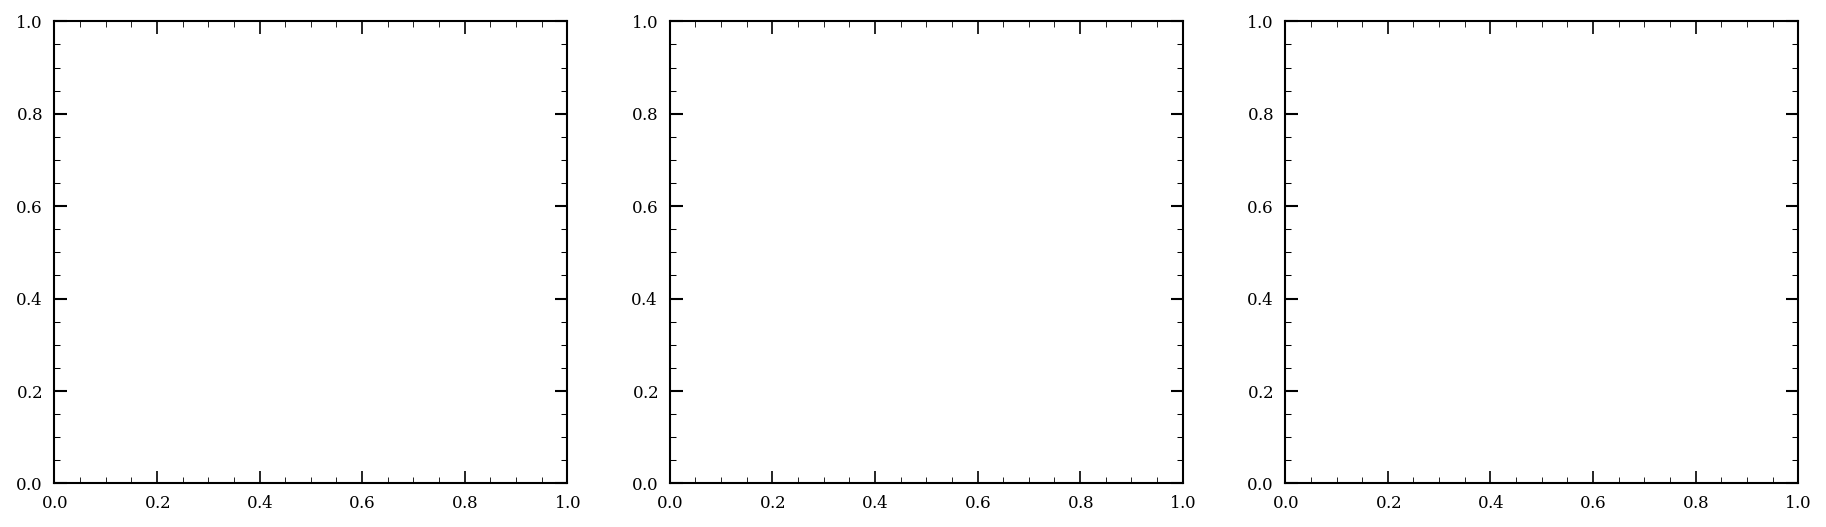

In [ ]:
# Create figure with 3 subplots in a row
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Marginal posterior over z
z_marginal_prior = torch.nanmean(p_prior, dim=2)
z_marginal_post = torch.nanmean(p_posterior, dim=2)

axes[0].contour(x_posterior, y_posterior, z_marginal_prior.T, cmap='Blues')
axes[0].contour(x_posterior, y_posterior, z_marginal_post.T, cmap='Reds')
axes[0].scatter(event_x, event_y, marker='*', linewidths=1, edgecolors='r', c='r', s=100, zorder=10)
axes[0].scatter(design_tmp[:, 0], design_tmp[:, 1], marker='^', linewidths=0, c='k', s=100, zorder=10)
axes[0].scatter(design[:, 0], design[:, 1], alpha=0.2, marker='^', linewidths=0, c='grey', s=100, zorder=10)        
axes[0].set_xlim(x_posterior.min(), x_posterior.max())
axes[0].set_ylim(y_posterior.min(), y_posterior.max())
axes[0].set_xlabel('Easting (m)')
axes[0].set_ylabel('Northing (m)')
axes[0].set_title('Marginal posterior over z')
axes[0].set_aspect('equal')

# Plot 2: x-z slice at event y location
xz_slice = p_posterior[:, int((event_y - y_posterior[0])//dx), :]
xz_slice_plot = xz_slice.clone()
xz_slice_plot[torch.isinf(xz_slice_plot)] = float('nan')

im2 = axes[1].pcolormesh(x_posterior, z_posterior, xz_slice_plot.T, shading='auto', cmap='Reds')

topo_xz_slice = topo_data.sel(northing=event_y, method='nearest')
axes[1].plot(topo_xz_slice['easting'], topo_xz_slice.values, color='k', linewidth=2, label='Topography')

axes[1].plot(event_x, event_z, 'ro', label='Event')
axes[1].set_xlabel('Easting (m)')
axes[1].set_ylabel('Elevation (m)')
axes[1].set_title(f'x-z slice at y={event_y:.0f}')
axes[1].scatter(design_tmp[:, 0], design_tmp[:, 2], marker='^', linewidths=0, c='k', s=100, zorder=10)
axes[1].scatter(design[:, 0], design[:, 2], alpha=0.2, marker='^', linewidths=0, c='grey', s=100, zorder=10)        
axes[1].set_xlim(x_posterior.min(), x_posterior.max())
axes[1].set_ylim(1400, 2600)
axes[1].set_aspect('equal')

# Plot 3: y-z slice at event x location
yz_slice = p_posterior[int((event_x - x_posterior[0])//dx), :, :]
yz_slice_plot = yz_slice.clone()
yz_slice_plot[torch.isinf(yz_slice_plot)] = float('nan')

im3 = axes[2].pcolormesh(y_posterior, z_posterior, yz_slice_plot.T, shading='auto', cmap='Reds')

topo_yz_slice = topo_data.sel(easting=event_x, method='nearest')
axes[2].plot(topo_yz_slice['northing'], topo_yz_slice.values, color='k', linewidth=2, label='Topography')

axes[2].plot(event_y, event_z, 'ro', label='Event')
axes[2].set_xlabel('Northing (m)')
axes[2].set_ylabel('Elevation (m)')
axes[2].set_title(f'y-z slice at x={event_x:.0f}')
axes[2].scatter(design_tmp[:, 1], design_tmp[:, 2], marker='^', linewidths=0, c='k', s=100, zorder=10)
axes[2].scatter(design[:, 1], design[:, 2], alpha=0.2, marker='^', linewidths=0, c='grey', s=100, zorder=10)   
axes[2].set_xlim(y_posterior.min(), y_posterior.max())
axes[2].set_ylim(1400, 2600)
axes[2].set_aspect('equal')


plt.tight_layout()
plt.show()